In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Sat May 16 15:27:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import pandas as pd
from collections import Counter
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO, RTDETR

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

INTRAORAL_DATASET = BASE_DIR / "data_prepared" / "intraoral_caries_yolo"
DATA_YAML = INTRAORAL_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "intraoral_caries"
RESULTS_DIR = BASE_DIR / "results" / "intraoral_caries_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "intraoral_caries"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Intraoral dataset:", INTRAORAL_DATASET)
print("data.yaml:", DATA_YAML)
print("data.yaml var mı?:", DATA_YAML.exists())
print("runs dir:", RUNS_DIR)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Intraoral dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo
data.yaml: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/data.yaml
data.yaml var mı?: True
runs dir: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries


In [5]:
print(DATA_YAML.read_text())

path: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo
train: images/train
val: images/val
test: images/test

names:
  0: caries


In [6]:
def count_split(split):
    img_dir = INTRAORAL_DATASET / "images" / split
    label_dir = INTRAORAL_DATASET / "labels" / split

    img_count = len(list(img_dir.glob("*")))
    label_count = len(list(label_dir.glob("*.txt")))

    return img_count, label_count

rows = []

for split in ["train", "val", "test"]:
    img_count, label_count = count_split(split)
    rows.append({
        "split": split,
        "images": img_count,
        "labels": label_count
    })

df_split_counts = pd.DataFrame(rows)
df_split_counts

,split,images,labels
0,train,1558,1558
1,val,400,400
2,test,269,269


In [7]:
class_names = {
    0: "caries"
}

counter = Counter()

label_dirs = [
    INTRAORAL_DATASET / "labels" / "train",
    INTRAORAL_DATASET / "labels" / "val",
    INTRAORAL_DATASET / "labels" / "test"
]

label_paths = []

for label_dir in label_dirs:
    label_paths.extend(list(label_dir.glob("*.txt")))

print("Toplam label dosyası:", len(label_paths))

for label_path in label_paths:
    lines = label_path.read_text(errors="ignore").strip().splitlines()

    for line in lines:
        if line.strip() == "":
            continue

        cls_id = int(float(line.split()[0]))
        counter[cls_id] += 1

df_class_counts = pd.DataFrame([
    {
        "class_id": cls_id,
        "class_name": class_names.get(cls_id, f"class_{cls_id}"),
        "count": count
    }
    for cls_id, count in sorted(counter.items())
])

df_class_counts

Toplam label dosyası: 2227


,class_id,class_name,count
0,0,caries,6728


In [8]:
def count_classes_by_split(dataset_dir):
    rows = []

    for split in ["train", "val", "test"]:
        label_dir = dataset_dir / "labels" / split
        split_counter = Counter()

        label_paths = list(label_dir.glob("*.txt"))
        print(split, "label dosyası:", len(label_paths))

        for label_path in label_paths:
            lines = label_path.read_text(errors="ignore").strip().splitlines()

            for line in lines:
                if line.strip() == "":
                    continue

                cls_id = int(float(line.split()[0]))
                split_counter[cls_id] += 1

        for cls_id, count in sorted(split_counter.items()):
            rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": class_names.get(cls_id, f"class_{cls_id}"),
                "count": count
            })

    return pd.DataFrame(rows)

df_split_class_counts = count_classes_by_split(INTRAORAL_DATASET)
df_split_class_counts

train label dosyası: 1558
val label dosyası: 400
test label dosyası: 269


,split,class_id,class_name,count
0,train,0,caries,4718
1,val,0,caries,1239
2,test,0,caries,771


In [9]:
experiments = [
    {
        "model_name": "YOLOv8n",
        "model_type": "yolo",
        "weights": "yolov8n.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8n_640_30ep"
    },
    {
        "model_name": "YOLOv8s",
        "model_type": "yolo",
        "weights": "yolov8s.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8s_640_30ep"
    },
    {
        "model_name": "YOLOv8m",
        "model_type": "yolo",
        "weights": "yolov8m.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 4,
        "run_name": "yolov8m_640_30ep"
    },
    {
        "model_name": "YOLO11s",
        "model_type": "yolo",
        "weights": "yolo11s.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolo11s_640_30ep"
    },
    {
        "model_name": "RT-DETR-l",
        "model_type": "rtdetr",
        "weights": "rtdetr-l.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 4,
        "run_name": "rtdetr_l_640_30ep"
    }
]

pd.DataFrame(experiments)

,model_name,model_type,weights,imgsz,epochs,batch,run_name
0,YOLOv8n,yolo,yolov8n.pt,640,30,8,yolov8n_640_30ep
1,YOLOv8s,yolo,yolov8s.pt,640,30,8,yolov8s_640_30ep
2,YOLOv8m,yolo,yolov8m.pt,640,30,4,yolov8m_640_30ep
3,YOLO11s,yolo,yolo11s.pt,640,30,8,yolo11s_640_30ep
4,RT-DETR-l,rtdetr,rtdetr-l.pt,640,30,4,rtdetr_l_640_30ep


In [10]:
def load_model(exp):
    if exp["model_type"] == "rtdetr":
        return RTDETR(exp["weights"])
    else:
        return YOLO(exp["weights"])

In [11]:
def train_and_evaluate_detection(exp):
    print("\n" + "=" * 120)
    print("DENEY BAŞLIYOR:", exp["run_name"])
    print("Model:", exp["model_name"])
    print("Weights:", exp["weights"])
    print("imgsz:", exp["imgsz"], "| epochs:", exp["epochs"], "| batch:", exp["batch"])
    print("=" * 120)

    try:
        model = load_model(exp)

        model.train(
            data=str(DATA_YAML),
            epochs=exp["epochs"],
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=exp["run_name"],
            exist_ok=True,
            patience=10,
            workers=2,
            cache=False
        )

        exp_dir = RUNS_DIR / exp["run_name"]
        best_model_path = exp_dir / "weights" / "best.pt"

        print("\nBest model path:", best_model_path)
        print("Best var mı?:", best_model_path.exists())

        if not best_model_path.exists():
            raise FileNotFoundError(f"best.pt bulunamadı: {best_model_path}")

        if exp["model_type"] == "rtdetr":
            best_model = RTDETR(str(best_model_path))
        else:
            best_model = YOLO(str(best_model_path))

        test_name = exp["run_name"] + "_test"

        test_metrics = best_model.val(
            data=str(DATA_YAML),
            split="test",
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=test_name,
            exist_ok=True
        )

        summary = {
            "status": "ok",
            "model": exp["model_name"],
            "model_type": exp["model_type"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],
            "precision": float(test_metrics.box.mp),
            "recall": float(test_metrics.box.mr),
            "mAP50": float(test_metrics.box.map50),
            "mAP50-95": float(test_metrics.box.map),
            "best_model_path": str(best_model_path),
            "error": ""
        }

        print("\nTEST SONUCU:")
        display(pd.DataFrame([summary]))

        return summary

    except Exception as e:
        print("\nHATA OLUŞTU:", exp["run_name"])
        print(str(e))

        summary = {
            "status": "failed",
            "model": exp["model_name"],
            "model_type": exp["model_type"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],
            "precision": None,
            "recall": None,
            "mAP50": None,
            "mAP50-95": None,
            "best_model_path": "",
            "error": str(e)
        }

        return summary

In [12]:
all_results = []

for exp in experiments:
    result = train_and_evaluate_detection(exp)
    all_results.append(result)

    # Her deneyden sonra ara kayıt
    df_temp = pd.DataFrame(all_results)
    temp_csv = RESULTS_DIR / "intraoral_caries_model_comparison_running.csv"
    df_temp.to_csv(temp_csv, index=False)
    print("Ara sonuç kaydedildi:", temp_csv)

df_all_results = pd.DataFrame(all_results)
df_all_results


DENEY BAŞLIYOR: yolov8n_640_30ep
Model: YOLOv8n
Weights: yolov8n.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8s_640_30ep
Model: YOLOv8s
Weights: yolov8s.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.92607,0.945,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8m_640_30ep
Model: YOLOv8m
Weights: yolov8m.pt
imgsz: 640 | epochs: 30 | batch: 4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      3.75G     0.2079     0.3808     0.1057         11        640: 100% ━━━━━━━━━━━━ 386/386 9.0it/s 42.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 33.4it/s 1.5s
                   all        399       1238      0.868      0.914      0.954      0.766

30 epochs completed in 0.368 hours.
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P         

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_running.csv


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


In [13]:
df_success = df_all_results[df_all_results["status"] == "ok"].copy()
df_success

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


In [14]:
df_results_sorted = df_success.sort_values("mAP50", ascending=False)
df_results_sorted

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


In [15]:
compare_csv = RESULTS_DIR / "intraoral_caries_model_comparison_first_round_30ep.csv"

df_results_sorted.to_csv(compare_csv, index=False)

print("Karşılaştırma kaydedildi:")
print(compare_csv)

Karşılaştırma kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_first_round_30ep.csv


In [16]:
best_row = df_results_sorted.iloc[0]

best_model_name = best_row["model"]
best_model_type = best_row["model_type"]
best_run_name = best_row["run_name"]
best_model_path = Path(best_row["best_model_path"])

print("İlk tur en iyi Intraoral Caries modeli:")
print("Model:", best_model_name)
print("Model type:", best_model_type)
print("Run:", best_run_name)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("mAP50:", best_row["mAP50"])
print("mAP50-95:", best_row["mAP50-95"])
print("Best path:", best_model_path)

İlk tur en iyi Intraoral Caries modeli:
Model: RT-DETR-l
Model type: rtdetr
Run: rtdetr_l_640_30ep
Precision: 0.8876441609637599
Recall: 0.8897535667963683
mAP50: 0.9502949068602573
mAP50-95: 0.7583481386863652
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt


In [17]:
final_model_path = FINAL_MODELS_DIR / f"{best_run_name}_best.pt"

shutil.copy2(best_model_path, final_model_path)

print("Final model kopyalandı:")
print(final_model_path)

Final model kopyalandı:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries/rtdetr_l_640_30ep_best.pt


In [18]:
if best_model_type == "rtdetr":
    best_model = RTDETR(str(best_model_path))
else:
    best_model = YOLO(str(best_model_path))

split_summaries = []

for split in ["train", "val", "test"]:
    print("\n" + "=" * 80)
    print("Değerlendirilen split:", split)
    print("=" * 80)

    metrics = best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=int(best_row["imgsz"]),
        batch=int(best_row["batch"]),
        device=0,
        project=str(RUNS_DIR),
        name=f"{best_run_name}_{split}_check",
        exist_ok=True
    )

    split_summaries.append({
        "model": best_model_name,
        "run_name": best_run_name,
        "split": split,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    })

df_best_split_metrics = pd.DataFrame(split_summaries)
df_best_split_metrics


Değerlendirilen split: train
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 350.6±231.8 MB/s, size: 198.5 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/labels/train.cache... 1558 images, 40 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 1558/1558 933.5Mit/s 0.0s
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/train/anonymous_003-007-1141-01_1732595713489_Frontal_View.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.5364]
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/train/anonymous_003-007-1209-01_1732857661861_Frontal_View.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.5371]
train: /c

,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,train,0.925269,0.953018,0.977394,0.806950
1,RT-DETR-l,rtdetr_l_640_30ep,val,0.868856,0.915116,0.954302,0.766464
2,RT-DETR-l,rtdetr_l_640_30ep,test,0.887644,0.889754,0.950295,0.758348


In [19]:
split_metrics_csv = RESULTS_DIR / f"{best_run_name}_train_val_test_metrics.csv"

df_best_split_metrics.to_csv(split_metrics_csv, index=False)

print("Kaydedildi:", split_metrics_csv)

Kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/rtdetr_l_640_30ep_train_val_test_metrics.csv


In [20]:
pred_name = best_run_name + "_predictions_conf25"

pred_result = best_model.predict(
    source=str(INTRAORAL_DATASET / "images" / "test"),
    imgsz=int(best_row["imgsz"]),
    conf=0.25,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1726825874701.jpg: 640x640 1 caries, 11.4ms
image 2/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727428268803.jpg: 640x640 1 caries, 12.4ms
image 3/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727777891803.jpg: 640x640 1 caries, 12.2ms
image 4/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727778270339.jpg: 640x640 (no detections), 12.0ms
image 5/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-leftLateralView-1727086025978.jpg: 640x640 (no detections), 11.8ms
image 6/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-leftLateralView-1727089857497.jpg: 640x640 1 ca

In [21]:
pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [22]:
print("Intraoral Caries ilk tur model karşılaştırması tamamlandı.")
print("=" * 100)

print("Karşılaştırma CSV:", compare_csv)
print("En iyi model:", best_model_name)
print("En iyi run:", best_run_name)
print("Final model:", final_model_path)

display(df_results_sorted)
display(df_best_split_metrics)

Intraoral Caries ilk tur model karşılaştırması tamamlandı.
Karşılaştırma CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_first_round_30ep.csv
En iyi model: RT-DETR-l
En iyi run: rtdetr_l_640_30ep
Final model: /content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries/rtdetr_l_640_30ep_best.pt


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,train,0.925269,0.953018,0.977394,0.806950
1,RT-DETR-l,rtdetr_l_640_30ep,val,0.868856,0.915116,0.954302,0.766464
2,RT-DETR-l,rtdetr_l_640_30ep,test,0.887644,0.889754,0.950295,0.758348


In [23]:
from pathlib import Path
import pandas as pd
import shutil
from ultralytics import RTDETR, YOLO

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

INTRAORAL_DATASET = BASE_DIR / "data_prepared" / "intraoral_caries_yolo"
DATA_YAML = INTRAORAL_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "intraoral_caries"
RESULTS_DIR = BASE_DIR / "results" / "intraoral_caries_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "intraoral_caries"

FIRST_ROUND_BEST = RUNS_DIR / "rtdetr_l_640_30ep" / "weights" / "best.pt"

print("İlk tur en iyi model:")
print(FIRST_ROUND_BEST)
print("Var mı?:", FIRST_ROUND_BEST.exists())

İlk tur en iyi model:
/content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt
Var mı?: True


In [24]:
final_exp = {
    "model_name": "RT-DETR-l",
    "model_type": "rtdetr",
    "weights": str(FIRST_ROUND_BEST),
    "imgsz": 768,
    "epochs": 75,
    "batch": 4,
    "run_name": "rtdetr_l_768_75ep_finetune"
}

final_exp

{'model_name': 'RT-DETR-l',
 'model_type': 'rtdetr',
 'weights': '/content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt',
 'imgsz': 768,
 'epochs': 75,
 'batch': 4,
 'run_name': 'rtdetr_l_768_75ep_finetune'}

In [25]:
final_model = RTDETR(final_exp["weights"])

final_model.train(
    data=str(DATA_YAML),
    epochs=final_exp["epochs"],
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"],
    exist_ok=True,
    patience=20,
    workers=2,
    cache=False,
    optimizer="AdamW",
    lr0=0.0001,
    weight_decay=0.0005
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/75      4.63G     0.9013     0.7304     0.4185         12        768: 100% ━━━━━━━━━━━━ 386/386 7.7it/s 50.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 14.8it/s 3.4s
                   all        399       1238       0.19      0.647      0.248       0.13

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/75      4.91G     0.4772     0.9446     0.2075         14        768: 0% ──────────── 1/386 2.8it/s 0.2s<2:20

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/75      4.91G     0.4543     0.9184     0.1823         16        768: 100% ━━━━━━━━━━━━ 386/386 8.9it/s 43.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 29.3it/s 1.7s
                   all        399       1238       0.22      0.575      0.234      0.169

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/75      4.91G     0.3486      0.923     0.1338         19        768: 0% ──────────── 1/386 2.7it/s 0.2s<2:20

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      44/75      4.91G     0.2138     0.3839    0.08981          7        768: 100% ━━━━━━━━━━━━ 386/386 9.0it/s 42.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 29.5it/s 1.7s
                   all        399       1238      0.872       0.88       0.92      0.731

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      45/75      4.91G     0.1952     0.3836    0.06887         41        768: 0% ──────────── 1/386 2.9it/s 0.2s<2:15

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      45/75      4.92G     0.2147     0.3837    0.08915         10        768: 100% ━━━━━━━━━━━━ 386/386 8.9it/s 43.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 28.9it/s 1.7s
                   all        399       1238      0.871      0.889      0.918      0.732
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 25, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

45 epochs completed in 0.572 hours.
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_768_75ep_finetune/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_768_75ep_finetune/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtde

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e780e1370b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [26]:
FINAL_EXP_DIR = RUNS_DIR / final_exp["run_name"]

print("Final deney klasörü:", FINAL_EXP_DIR)
print("Var mı?:", FINAL_EXP_DIR.exists())

if FINAL_EXP_DIR.exists():
    for p in FINAL_EXP_DIR.iterdir():
        print(p.name)

Final deney klasörü: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_768_75ep_finetune
Var mı?: True
weights
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
results.csv
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch2_labels.jpg
val_batch1_pred.jpg
val_batch2_pred.jpg
BoxPR_curve.png
BoxF1_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix_normalized.png
confusion_matrix.png
results.png


In [27]:
final_results_csv = FINAL_EXP_DIR / "results.csv"

print("results.csv var mı?:", final_results_csv.exists())

df_final_results = pd.read_csv(final_results_csv)
df_final_results.tail(10)

results.csv var mı?: True


,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
35,36,1653.48,0.21984,0.38318,0.09214,0.86577,0.88571,0.92696,0.73855,0.23163,0.45467,0.12444,0.000054,0.000054,0.000054
36,37,1697.60,0.22124,0.38395,0.09169,0.87658,0.88126,0.92966,0.73998,0.22894,0.45013,0.12272,0.000052,0.000052,0.000052
37,38,1742.89,0.22174,0.38397,0.09105,0.87603,0.86757,0.91666,0.72934,0.23210,0.47859,0.12420,0.000051,0.000051,0.000051
38,39,1787.98,0.22241,0.39354,0.09435,0.88071,0.87664,0.92387,0.73697,0.23318,0.47430,0.12458,0.000050,0.000050,0.000050
39,40,1833.55,0.21873,0.38570,0.09018,0.87253,0.89499,0.92357,0.73728,0.22921,0.47760,0.12232,0.000049,0.000049,0.000049
40,41,1877.98,0.22014,0.38298,0.09112,0.87034,0.88377,0.92440,0.73792,0.22828,0.45445,0.12205,0.000047,0.000047,0.000047
41,42,1922.82,0.21887,0.37854,0.09088,0.87130,0.88934,0.92568,0.73733,0.22708,0.45810,0.12128,0.000046,0.000046,0.000046
42,43,1968.04,0.21688,0.38110,0.09172,0.86820,0.88857,0.92688,0.73756,0.23779,0.47422,0.12737,0.000045,0.000045,0.000045
43,44,2013.11,0.21376,0.38390,0.08981,0.87202,0.87964,0.92018,0.73053,0.23150,0.46896,0.12313,0.000043,0.000043,0.000043
44,45,2058.53,0.21475,0.38370,0.08915,0.87068,0.88934,0.91778,0.73186,0.23439,0.46442,0.12470,0.000042,0.000042,0.000042


In [28]:
final_best_model_path = FINAL_EXP_DIR / "weights" / "best.pt"
final_last_model_path = FINAL_EXP_DIR / "weights" / "last.pt"

print("best.pt var mı?:", final_best_model_path.exists())
print("last.pt var mı?:", final_last_model_path.exists())

print("Best path:", final_best_model_path)

best.pt var mı?: True
last.pt var mı?: True
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_768_75ep_finetune/weights/best.pt


In [29]:
final_best_model = RTDETR(str(final_best_model_path))

final_test_metrics = final_best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"] + "_test",
    exist_ok=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 197.5±140.8 MB/s, size: 137.0 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/labels/test.cache... 269 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 269/269 125.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 35.5it/s 1.9s
                   all        269        771      0.881      0.874      0.927      0.737
Speed: 0.3ms preprocess, 5.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_768_75ep_finetune_test


In [30]:
df_final_metrics = pd.DataFrame([{
    "model": "RT-DETR-l",
    "run_name": final_exp["run_name"],
    "imgsz": final_exp["imgsz"],
    "epochs": final_exp["epochs"],
    "batch": final_exp["batch"],
    "precision": float(final_test_metrics.box.mp),
    "recall": float(final_test_metrics.box.mr),
    "mAP50": float(final_test_metrics.box.map50),
    "mAP50-95": float(final_test_metrics.box.map),
    "best_model_path": str(final_best_model_path)
}])

df_final_metrics

,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path
0,RT-DETR-l,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...


In [31]:
split_summaries = []

for split in ["train", "val", "test"]:
    print("\n" + "=" * 80)
    print("Split:", split)
    print("=" * 80)

    metrics = final_best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=final_exp["imgsz"],
        batch=final_exp["batch"],
        device=0,
        project=str(RUNS_DIR),
        name=f"{final_exp['run_name']}_{split}_check",
        exist_ok=True
    )

    split_summaries.append({
        "model": "RT-DETR-l",
        "run_name": final_exp["run_name"],
        "split": split,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    })

df_final_split_metrics = pd.DataFrame(split_summaries)
df_final_split_metrics


Split: train
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 244.2±159.5 MB/s, size: 198.5 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/labels/train.cache... 1558 images, 40 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 1558/1558 594.1Mit/s 0.0s
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/train/anonymous_003-007-1141-01_1732595713489_Frontal_View.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.5364]
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/train/anonymous_003-007-1209-01_1732857661861_Frontal_View.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.5371]
train: /content/drive/MyD

,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_768_75ep_finetune,train,0.931240,0.967501,0.972812,0.803942
1,RT-DETR-l,rtdetr_l_768_75ep_finetune,val,0.842254,0.918639,0.934868,0.745181
2,RT-DETR-l,rtdetr_l_768_75ep_finetune,test,0.880746,0.874189,0.927027,0.736956


In [32]:
first_round_best = {
    "model": "RT-DETR-l",
    "run_name": "rtdetr_l_640_30ep",
    "imgsz": 640,
    "epochs": 30,
    "batch": 4,
    "precision": 0.887644,
    "recall": 0.889754,
    "mAP50": 0.950295,
    "mAP50-95": 0.758348
}

df_compare_final = pd.concat([
    pd.DataFrame([first_round_best]),
    df_final_metrics[[
        "model", "run_name", "imgsz", "epochs", "batch",
        "precision", "recall", "mAP50", "mAP50-95"
    ]]
], ignore_index=True)

df_compare_final

,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348
1,RT-DETR-l,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956


In [33]:
final_metrics_csv = RESULTS_DIR / f"intraoral_{final_exp['run_name']}_final_metrics.csv"
final_split_csv = RESULTS_DIR / f"intraoral_{final_exp['run_name']}_split_metrics.csv"
final_compare_csv = RESULTS_DIR / f"intraoral_rtdetr_first_vs_{final_exp['run_name']}_comparison.csv"

df_final_metrics.to_csv(final_metrics_csv, index=False)
df_final_split_metrics.to_csv(final_split_csv, index=False)
df_compare_final.to_csv(final_compare_csv, index=False)

print("Kaydedildi:")
print(final_metrics_csv)
print(final_split_csv)
print(final_compare_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_rtdetr_l_768_75ep_finetune_final_metrics.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_rtdetr_l_768_75ep_finetune_split_metrics.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_rtdetr_first_vs_rtdetr_l_768_75ep_finetune_comparison.csv


In [34]:
final_saved_model_path = FINAL_MODELS_DIR / f"intraoral_{final_exp['run_name']}_best.pt"

shutil.copy2(final_best_model_path, final_saved_model_path)

print("Final Intraoral Caries modeli kaydedildi:")
print(final_saved_model_path)

Final Intraoral Caries modeli kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries/intraoral_rtdetr_l_768_75ep_finetune_best.pt


In [35]:
pred_name = final_exp["run_name"] + "_predictions_conf25"

pred_result = final_best_model.predict(
    source=str(INTRAORAL_DATASET / "images" / "test"),
    imgsz=final_exp["imgsz"],
    conf=0.25,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1726825874701.jpg: 768x768 2 cariess, 11.8ms
image 2/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727428268803.jpg: 768x768 2 cariess, 12.0ms
image 3/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727777891803.jpg: 768x768 1 caries, 12.3ms
image 4/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-frontalView-1727778270339.jpg: 768x768 1 caries, 12.1ms
image 5/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-leftLateralView-1727086025978.jpg: 768x768 1 caries, 11.9ms
image 6/269 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/intraoral_caries_yolo/images/test/anonymous-leftLateralView-1727089857497.jpg: 768x768 (no detections),

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import random

pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [37]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import shutil

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

RESULTS_DIR = BASE_DIR / "results" / "intraoral_caries_training"
RUNS_DIR = BASE_DIR / "runs" / "intraoral_caries"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "intraoral_caries"

FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_DIR:", RESULTS_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("FINAL_MODELS_DIR:", FINAL_MODELS_DIR)

RESULTS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training
RUNS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries
FINAL_MODELS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries


In [38]:
first_round_csv = RESULTS_DIR / "intraoral_caries_model_comparison_first_round_30ep.csv"

print("İlk tur CSV:", first_round_csv)
print("Var mı?:", first_round_csv.exists())

df_first_round = pd.read_csv(first_round_csv)

df_first_round

İlk tur CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_caries_model_comparison_first_round_30ep.csv
Var mı?: True


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN
1,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN
2,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN
3,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN
4,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN


In [39]:
df_final_manual = pd.DataFrame([
    {
        "status": "ok",
        "model": "RT-DETR-l",
        "model_type": "rtdetr",
        "weights": "rtdetr_l_640_30ep_best.pt",
        "run_name": "rtdetr_l_768_75ep_finetune",
        "imgsz": 768,
        "epochs": 75,
        "batch": 4,
        "precision": 0.880746,
        "recall": 0.874189,
        "mAP50": 0.927027,
        "mAP50-95": 0.736956,
        "best_model_path": str(RUNS_DIR / "rtdetr_l_768_75ep_finetune" / "weights" / "best.pt"),
        "error": ""
    }
])

df_final_manual

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,


In [40]:
needed_cols = [
    "status", "model", "model_type", "weights", "run_name",
    "imgsz", "epochs", "batch",
    "precision", "recall", "mAP50", "mAP50-95",
    "best_model_path", "error"
]

df_first_clean = df_first_round.copy()

for col in needed_cols:
    if col not in df_first_clean.columns:
        df_first_clean[col] = None

df_first_clean = df_first_clean[needed_cols]
df_first_clean["experiment_type"] = "first_round"


df_final_clean = df_final_manual.copy()

for col in needed_cols:
    if col not in df_final_clean.columns:
        df_final_clean[col] = None

df_final_clean = df_final_clean[needed_cols]
df_final_clean["experiment_type"] = "fine_tune"


df_intraoral_all_models = pd.concat(
    [df_first_clean, df_final_clean],
    ignore_index=True
)

df_intraoral_all_models = df_intraoral_all_models.sort_values(
    "mAP50",
    ascending=False
).reset_index(drop=True)

df_intraoral_all_models

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error,experiment_type
0,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN,first_round
1,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN,first_round
2,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN,first_round
3,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN,first_round
4,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,NaN,first_round
5,ok,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...,,fine_tune


In [41]:
df_intraoral_comparison = df_intraoral_all_models[[
    "experiment_type",
    "model",
    "model_type",
    "weights",
    "run_name",
    "imgsz",
    "epochs",
    "batch",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95"
]].copy()

metric_cols = ["precision", "recall", "mAP50", "mAP50-95"]

for col in metric_cols:
    df_intraoral_comparison[col] = df_intraoral_comparison[col].astype(float).round(6)

df_intraoral_comparison

,experiment_type,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,first_round,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348
1,first_round,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717
2,first_round,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569
3,first_round,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183
4,first_round,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131
5,fine_tune,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956


In [42]:
best_model_row = df_intraoral_comparison.iloc[0]

print("Intraoral Caries için en iyi model:")
print("=" * 80)
print("Model:", best_model_row["model"])
print("Run:", best_model_row["run_name"])
print("Experiment type:", best_model_row["experiment_type"])
print("Image size:", best_model_row["imgsz"])
print("Epochs:", best_model_row["epochs"])
print("Batch:", best_model_row["batch"])
print("Precision:", best_model_row["precision"])
print("Recall:", best_model_row["recall"])
print("mAP50:", best_model_row["mAP50"])
print("mAP50-95:", best_model_row["mAP50-95"])

Intraoral Caries için en iyi model:
Model: RT-DETR-l
Run: rtdetr_l_640_30ep
Experiment type: first_round
Image size: 640
Epochs: 30
Batch: 4
Precision: 0.887644
Recall: 0.889754
mAP50: 0.950295
mAP50-95: 0.758348


In [43]:
selected_best_source = RUNS_DIR / "rtdetr_l_640_30ep" / "weights" / "best.pt"
selected_best_target = FINAL_MODELS_DIR / "intraoral_best_model_rtdetr_l_640_30ep.pt"

print("Kaynak:", selected_best_source)
print("Var mı?:", selected_best_source.exists())

shutil.copy2(selected_best_source, selected_best_target)

print("Final seçilen Intraoral Caries modeli kaydedildi:")
print(selected_best_target)

Kaynak: /content/drive/MyDrive/DIS_PROJESI_007/runs/intraoral_caries/rtdetr_l_640_30ep/weights/best.pt
Var mı?: True
Final seçilen Intraoral Caries modeli kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries/intraoral_best_model_rtdetr_l_640_30ep.pt


In [44]:
model_features = [
    {
        "model": "YOLOv8n",
        "architecture_type": "YOLO detection",
        "model_size": "nano",
        "task": "object detection",
        "description": "Hızlı ve hafif YOLOv8 modeli"
    },
    {
        "model": "YOLOv8s",
        "architecture_type": "YOLO detection",
        "model_size": "small",
        "task": "object detection",
        "description": "Hız ve başarı dengesi için kullanılan YOLOv8 modeli"
    },
    {
        "model": "YOLOv8m",
        "architecture_type": "YOLO detection",
        "model_size": "medium",
        "task": "object detection",
        "description": "Daha yüksek kapasiteye sahip YOLOv8 modeli"
    },
    {
        "model": "YOLO11s",
        "architecture_type": "YOLO detection",
        "model_size": "small",
        "task": "object detection",
        "description": "Güncel YOLO ailesinden küçük ölçekli detection modeli"
    },
    {
        "model": "RT-DETR-l",
        "architecture_type": "Transformer-based detection",
        "model_size": "large",
        "task": "object detection",
        "description": "Gerçek zamanlı Transformer tabanlı nesne tespit modeli"
    }
]

df_model_features = pd.DataFrame(model_features)

df_model_features

,model,architecture_type,model_size,task,description
0,YOLOv8n,YOLO detection,nano,object detection,Hızlı ve hafif YOLOv8 modeli
1,YOLOv8s,YOLO detection,small,object detection,Hız ve başarı dengesi için kullanılan YOLOv8 m...
2,YOLOv8m,YOLO detection,medium,object detection,Daha yüksek kapasiteye sahip YOLOv8 modeli
3,YOLO11s,YOLO detection,small,object detection,Güncel YOLO ailesinden küçük ölçekli detection...
4,RT-DETR-l,Transformer-based detection,large,object detection,Gerçek zamanlı Transformer tabanlı nesne tespi...


In [45]:
df_intraoral_report_table = df_intraoral_comparison.merge(
    df_model_features,
    on="model",
    how="left"
)

df_intraoral_report_table = df_intraoral_report_table[[
    "model",
    "architecture_type",
    "model_size",
    "task",
    "experiment_type",
    "imgsz",
    "epochs",
    "batch",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "run_name",
    "description"
]]

df_intraoral_report_table

,model,architecture_type,model_size,task,experiment_type,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,run_name,description
0,RT-DETR-l,Transformer-based detection,large,object detection,first_round,640,30,4,0.887644,0.889754,0.950295,0.758348,rtdetr_l_640_30ep,Gerçek zamanlı Transformer tabanlı nesne tespi...
1,YOLO11s,YOLO detection,small,object detection,first_round,640,30,8,0.877600,0.884565,0.949497,0.754717,yolo11s_640_30ep,Güncel YOLO ailesinden küçük ölçekli detection...
2,YOLOv8n,YOLO detection,nano,object detection,first_round,640,30,8,0.852988,0.909209,0.945375,0.748569,yolov8n_640_30ep,Hızlı ve hafif YOLOv8 modeli
3,YOLOv8s,YOLO detection,small,object detection,first_round,640,30,8,0.849631,0.926070,0.945000,0.747183,yolov8s_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 m...
4,YOLOv8m,YOLO detection,medium,object detection,first_round,640,30,4,0.836954,0.907912,0.943005,0.747131,yolov8m_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 modeli
5,RT-DETR-l,Transformer-based detection,large,object detection,fine_tune,768,75,4,0.880746,0.874189,0.927027,0.736956,rtdetr_l_768_75ep_finetune,Gerçek zamanlı Transformer tabanlı nesne tespi...


In [46]:
comparison_output_csv = RESULTS_DIR / "intraoral_all_models_performance_comparison.csv"
report_output_csv = RESULTS_DIR / "intraoral_all_models_report_table.csv"
decision_output_csv = RESULTS_DIR / "intraoral_final_model_decision.csv"

df_intraoral_comparison.to_csv(comparison_output_csv, index=False)
df_intraoral_report_table.to_csv(report_output_csv, index=False)

decision_table = pd.DataFrame([
    {
        "selected_model": "RT-DETR-l",
        "selected_run": "rtdetr_l_640_30ep",
        "selected_reason": "highest mAP50 and mAP50-95 in first-round comparison",
        "precision": 0.887644,
        "recall": 0.889754,
        "mAP50": 0.950295,
        "mAP50-95": 0.758348,
        "final_model_path": str(selected_best_target)
    },
    {
        "selected_model": "RT-DETR-l",
        "selected_run": "rtdetr_l_768_75ep_finetune",
        "selected_reason": "not selected because fine-tuning decreased mAP values",
        "precision": 0.880746,
        "recall": 0.874189,
        "mAP50": 0.927027,
        "mAP50-95": 0.736956,
        "final_model_path": str(RUNS_DIR / "rtdetr_l_768_75ep_finetune" / "weights" / "best.pt")
    }
])

decision_table.to_csv(decision_output_csv, index=False)

print("Performans karşılaştırma tablosu kaydedildi:")
print(comparison_output_csv)

print("\nRapor tablosu kaydedildi:")
print(report_output_csv)

print("\nFinal karar tablosu kaydedildi:")
print(decision_output_csv)

Performans karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_all_models_performance_comparison.csv

Rapor tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_all_models_report_table.csv

Final karar tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_final_model_decision.csv


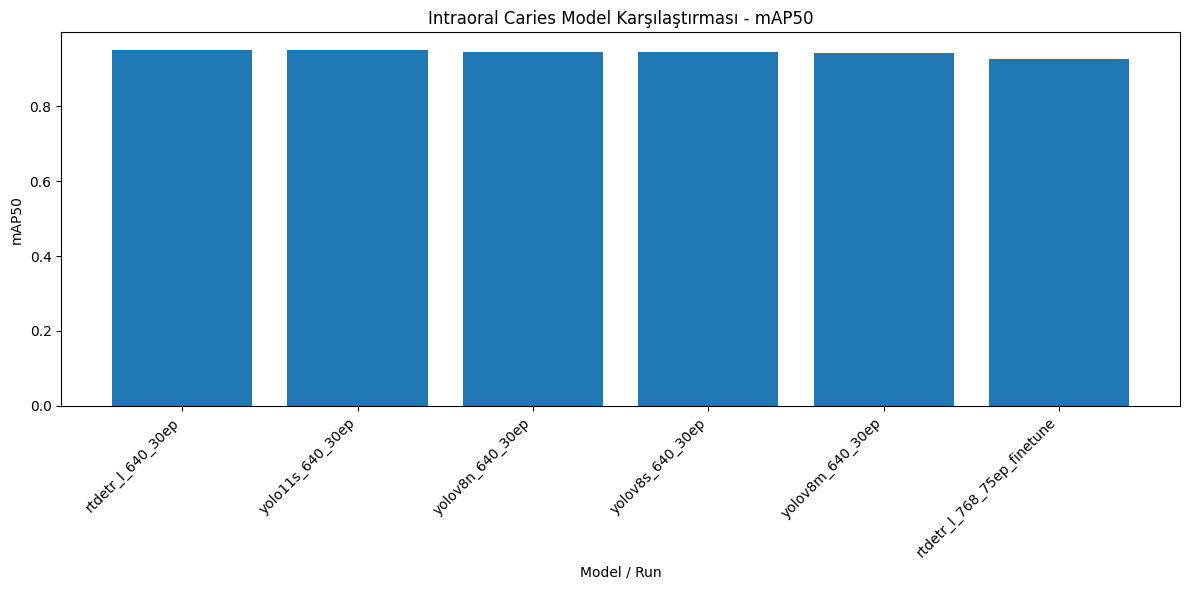

In [47]:
plot_df = df_intraoral_comparison.copy()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["run_name"], plot_df["mAP50"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Model / Run")
plt.ylabel("mAP50")
plt.title("Intraoral Caries Model Karşılaştırması - mAP50")
plt.tight_layout()
plt.show()

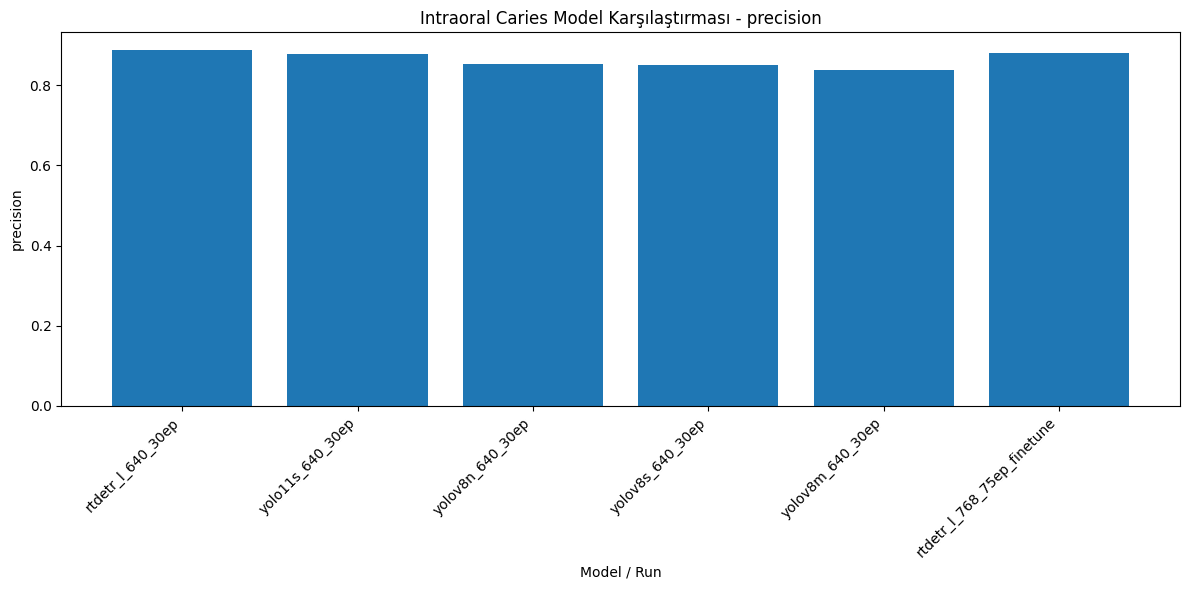

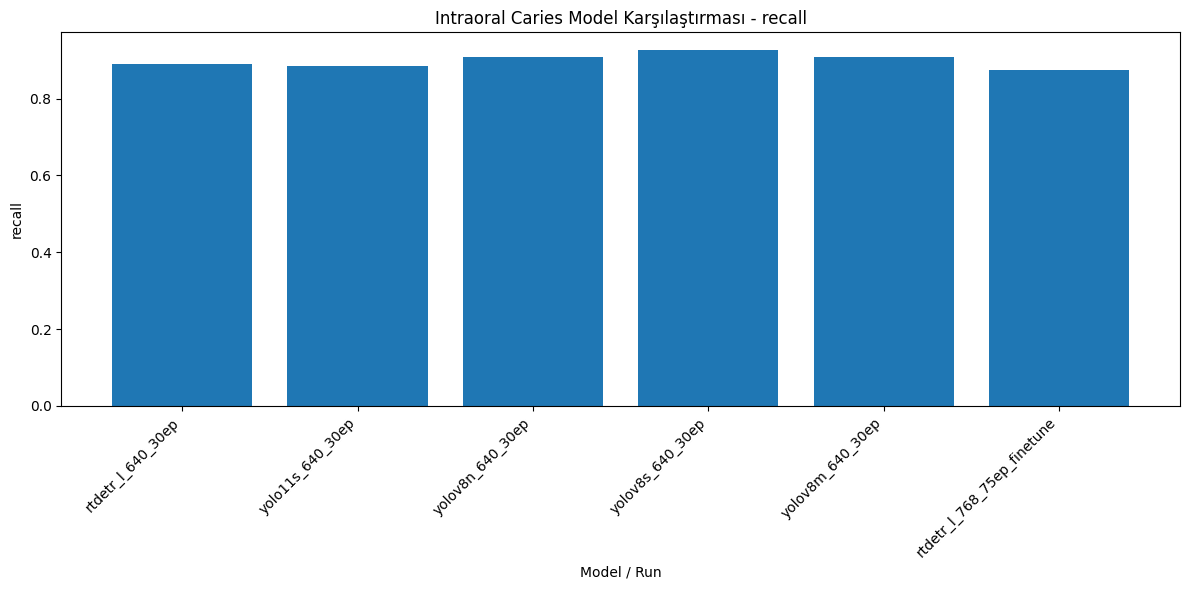

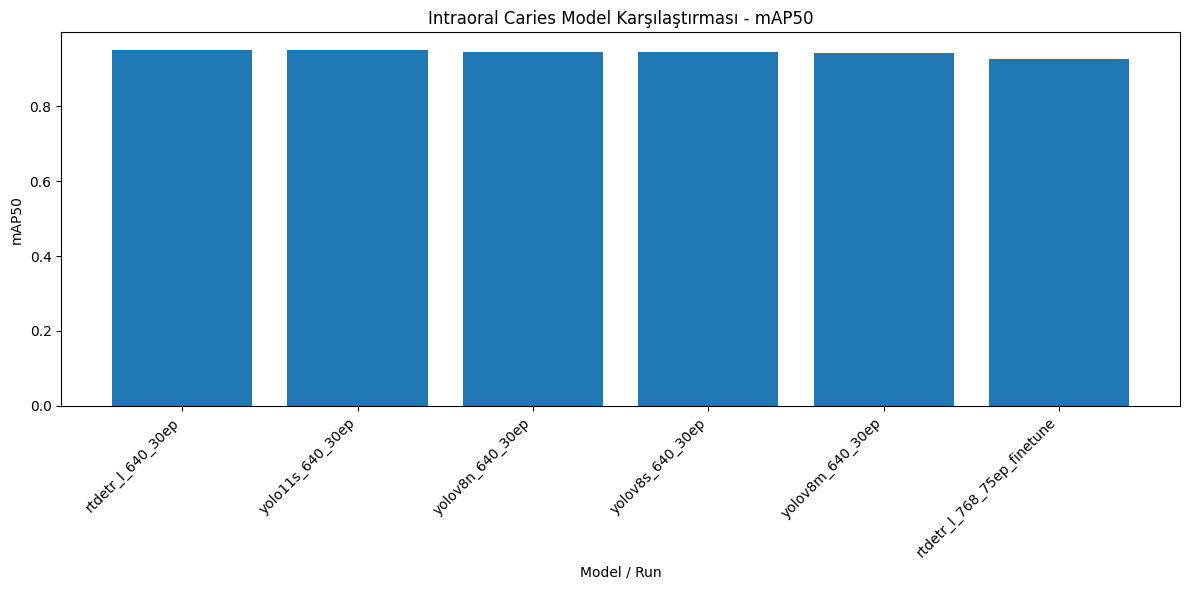

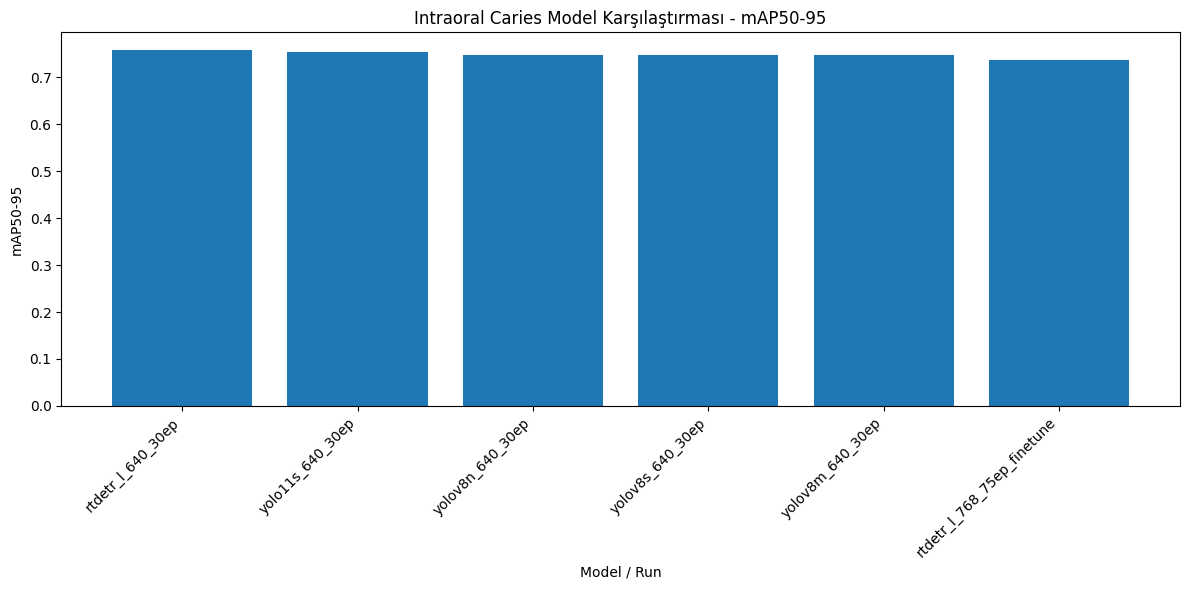

In [48]:
plot_df = df_intraoral_comparison.copy()

metrics = ["precision", "recall", "mAP50", "mAP50-95"]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["run_name"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Model / Run")
    plt.ylabel(metric)
    plt.title(f"Intraoral Caries Model Karşılaştırması - {metric}")
    plt.tight_layout()
    plt.show()

In [49]:
best_map50 = df_intraoral_comparison.iloc[0]["mAP50"]
best_run = df_intraoral_comparison.iloc[0]["run_name"]

comparison_rows = []

for _, row in df_intraoral_comparison.iterrows():
    diff = best_map50 - row["mAP50"]

    comparison_rows.append({
        "run_name": row["run_name"],
        "model": row["model"],
        "mAP50": row["mAP50"],
        "difference_from_best_mAP50": round(diff, 6),
        "selected_best": row["run_name"] == best_run
    })

df_best_comparison = pd.DataFrame(comparison_rows)

df_best_comparison

,run_name,model,mAP50,difference_from_best_mAP50,selected_best
0,rtdetr_l_640_30ep,RT-DETR-l,0.950295,0.000000,True
1,yolo11s_640_30ep,YOLO11s,0.949497,0.000798,False
2,yolov8n_640_30ep,YOLOv8n,0.945375,0.004920,False
3,yolov8s_640_30ep,YOLOv8s,0.945000,0.005295,False
4,yolov8m_640_30ep,YOLOv8m,0.943005,0.007290,False
5,rtdetr_l_768_75ep_finetune,RT-DETR-l,0.927027,0.023268,False


In [50]:
best = df_intraoral_comparison.iloc[0]

comment = f"""
Intraoral Caries veri seti üzerinde YOLOv8n, YOLOv8s, YOLOv8m, YOLO11s ve RT-DETR-l modelleri
30 epoch boyunca eğitilerek karşılaştırılmıştır. İlk tur deneylerinde en iyi sonuç {best['model']} modeli ile
elde edilmiştir. {best['run_name']} deneyinde model, {int(best['imgsz'])} görüntü boyutu,
{int(best['epochs'])} epoch ve batch={int(best['batch'])} ayarlarıyla eğitilmiş; test setinde
precision={best['precision']:.4f}, recall={best['recall']:.4f}, mAP50={best['mAP50']:.4f} ve
mAP50-95={best['mAP50-95']:.4f} değerlerine ulaşmıştır.

Daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle gerçekleştirilen RT-DETR-l 768/75 epoch fine-tune
denemesi, ilk turdaki RT-DETR-l 640/30 epoch modelinden daha düşük mAP değerleri vermiştir.
Bu nedenle Intraoral Caries veri seti için final model olarak RT-DETR-l 640/30 epoch modeli seçilmiştir.

Sonuçlar, ağız içi görüntülerde çürük bölgelerinin nesne tespiti yöntemiyle başarılı şekilde öğrenilebildiğini
göstermektedir. Bu veri setinde elde edilen yüksek mAP değerleri, DENTEX panoramik X-ray deneylerine kıyasla
ağız içi görüntülerde çürük bölgelerinin daha belirgin ve doğrudan etiketlenebilir olduğunu göstermektedir.
"""

print(comment)


Intraoral Caries veri seti üzerinde YOLOv8n, YOLOv8s, YOLOv8m, YOLO11s ve RT-DETR-l modelleri
30 epoch boyunca eğitilerek karşılaştırılmıştır. İlk tur deneylerinde en iyi sonuç RT-DETR-l modeli ile
elde edilmiştir. rtdetr_l_640_30ep deneyinde model, 640 görüntü boyutu,
30 epoch ve batch=4 ayarlarıyla eğitilmiş; test setinde
precision=0.8876, recall=0.8898, mAP50=0.9503 ve
mAP50-95=0.7583 değerlerine ulaşmıştır.

Daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle gerçekleştirilen RT-DETR-l 768/75 epoch fine-tune
denemesi, ilk turdaki RT-DETR-l 640/30 epoch modelinden daha düşük mAP değerleri vermiştir.
Bu nedenle Intraoral Caries veri seti için final model olarak RT-DETR-l 640/30 epoch modeli seçilmiştir.

Sonuçlar, ağız içi görüntülerde çürük bölgelerinin nesne tespiti yöntemiyle başarılı şekilde öğrenilebildiğini
göstermektedir. Bu veri setinde elde edilen yüksek mAP değerleri, DENTEX panoramik X-ray deneylerine kıyasla
ağız içi görüntülerde çürük bölgelerinin daha belirgin ve 

In [51]:
comment_path = RESULTS_DIR / "intraoral_model_comparison_comment.txt"

comment_path.write_text(comment, encoding="utf-8")

print("Yorum kaydedildi:")
print(comment_path)

Yorum kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_model_comparison_comment.txt


In [52]:
print("07 Intraoral Caries notebook tamamlandı.")
print("=" * 100)

print("Final seçilen model:")
print(selected_best_target)

print("\nKarşılaştırma tablosu:")
display(df_intraoral_comparison)

print("\nRapor tablosu:")
display(df_intraoral_report_table)

print("\nFinal karar:")
display(decision_table)

07 Intraoral Caries notebook tamamlandı.
Final seçilen model:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/intraoral_caries/intraoral_best_model_rtdetr_l_640_30ep.pt

Karşılaştırma tablosu:


,experiment_type,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,first_round,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.887644,0.889754,0.950295,0.758348
1,first_round,YOLO11s,yolo,yolo11s.pt,yolo11s_640_30ep,640,30,8,0.877600,0.884565,0.949497,0.754717
2,first_round,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.852988,0.909209,0.945375,0.748569
3,first_round,YOLOv8s,yolo,yolov8s.pt,yolov8s_640_30ep,640,30,8,0.849631,0.926070,0.945000,0.747183
4,first_round,YOLOv8m,yolo,yolov8m.pt,yolov8m_640_30ep,640,30,4,0.836954,0.907912,0.943005,0.747131
5,fine_tune,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_75ep_finetune,768,75,4,0.880746,0.874189,0.927027,0.736956



Rapor tablosu:


,model,architecture_type,model_size,task,experiment_type,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,run_name,description
0,RT-DETR-l,Transformer-based detection,large,object detection,first_round,640,30,4,0.887644,0.889754,0.950295,0.758348,rtdetr_l_640_30ep,Gerçek zamanlı Transformer tabanlı nesne tespi...
1,YOLO11s,YOLO detection,small,object detection,first_round,640,30,8,0.877600,0.884565,0.949497,0.754717,yolo11s_640_30ep,Güncel YOLO ailesinden küçük ölçekli detection...
2,YOLOv8n,YOLO detection,nano,object detection,first_round,640,30,8,0.852988,0.909209,0.945375,0.748569,yolov8n_640_30ep,Hızlı ve hafif YOLOv8 modeli
3,YOLOv8s,YOLO detection,small,object detection,first_round,640,30,8,0.849631,0.926070,0.945000,0.747183,yolov8s_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 m...
4,YOLOv8m,YOLO detection,medium,object detection,first_round,640,30,4,0.836954,0.907912,0.943005,0.747131,yolov8m_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 modeli
5,RT-DETR-l,Transformer-based detection,large,object detection,fine_tune,768,75,4,0.880746,0.874189,0.927027,0.736956,rtdetr_l_768_75ep_finetune,Gerçek zamanlı Transformer tabanlı nesne tespi...



Final karar:


,selected_model,selected_run,selected_reason,precision,recall,mAP50,mAP50-95,final_model_path
0,RT-DETR-l,rtdetr_l_640_30ep,highest mAP50 and mAP50-95 in first-round comp...,0.887644,0.889754,0.950295,0.758348,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
1,RT-DETR-l,rtdetr_l_768_75ep_finetune,not selected because fine-tuning decreased mAP...,0.880746,0.874189,0.927027,0.736956,/content/drive/MyDrive/DIS_PROJESI_007/runs/in...


In [53]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>